(mmm_campaign_media)=
# Campaign-Granularity MMM with `NestedCampaignMedia`

:::{warning}
**VERY EXPERIMENTAL.** The API, priors, and semantics of `NestedCampaignMedia` are all subject to change, and `MMM.save`/`load` does not round-trip the effect yet. This notebook demonstrates a draft feature.
:::

Media Mix Models usually stop at the **channel**: one saturation curve per channel, one ROI per channel. But budgets are planned at **campaign** level, and practitioners keep asking the MMM a question it cannot answer: *which campaign inside the channel is pulling the weight?*

Naively splitting a channel into campaigns fails in two opposite ways:

- **No pooling**: each campaign gets its own free parameters. Small campaigns (a 2% spend share is common) have almost no individual signal, so their posteriors are wide and their ROIs are noise.
- **Averaging**: report the channel ROI for every campaign, which is exactly the non-answer we started with.

`NestedCampaignMedia` takes the middle road, following three principles:

1. **Hierarchical pooling is the accuracy lever.** Campaign parameters are non-centred deviations under *channel-level* hyperpriors, so weakly-identified campaigns shrink toward their channel instead of chasing noise.
2. **Identification comes from the mix, not from a constraint.** Because $\sum_c f_c(x_c) \neq f(\sum_c x_c)$ for saturating $f$, weeks with different campaign mixes at the same channel total are informative. Flighting variation, dark weeks, per-campaign covariates, and lift tests are the signal sources; without them, campaign efficiency is *unidentified* and the pooling correctly returns the channel mean.
3. **Channel-level ROI must not be destabilised.** Campaign log-multipliers are constrained to a *spend-share-weighted zero sum* within each channel, so the channel-level parameters keep their meaning, and a channel roll-up deterministic is registered for direct comparison.

The effect **replaces** the channel-level media term for the channels it decomposes: those channels must be excluded from `channel_columns` (a `UserWarning` fires otherwise, because keeping both double-counts the spend).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.campaign_media import NestedCampaignMedia

seed = 20260825
rng = np.random.default_rng(seed)
az.style.use("arviz-darkgrid")

## Synthetic data with a known answer

Two channels: `search` stays at channel level; `social` is decomposed into three campaigns with a lopsided **70/20/10** average spend split. The ground truth is chosen so the smallest campaign is **twice as efficient** as its siblings — precisely the situation where a channel-level MMM is silently wrong and a no-pooling model is too noisy to notice.

The campaign spends get lognormal flighting noise and occasional dark weeks: that mix variation is what identifies the split.

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_25649/820562044.py:31: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


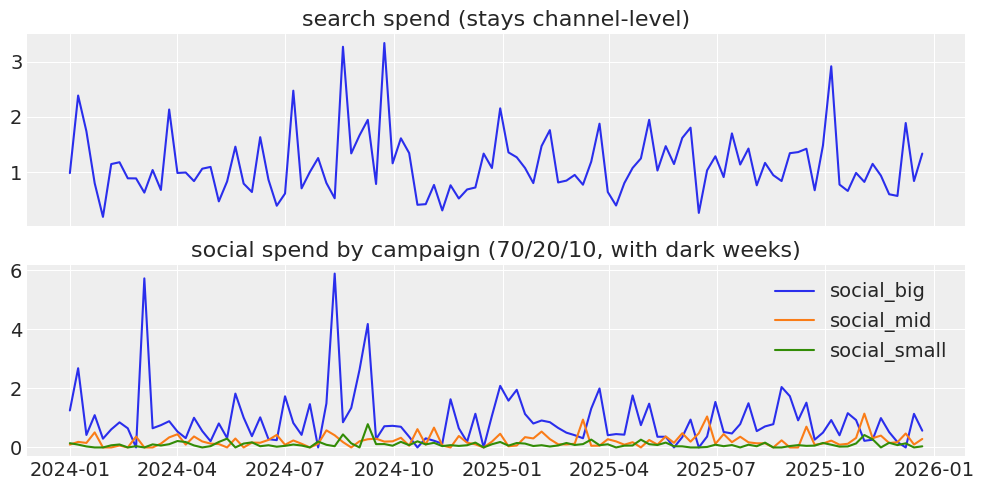

In [2]:
n_dates = 104
dates = pd.date_range("2024-01-01", periods=n_dates, freq="W-MON")
campaigns = ["social_big", "social_mid", "social_small"]
mapping = {c: "social" for c in campaigns}
shares = np.array([0.70, 0.20, 0.10])

search_spend = rng.lognormal(0, 0.5, n_dates)
campaign_spend = shares[None, :] * rng.lognormal(0, 0.7, size=(n_dates, 3))
for j in range(3):
    dark = rng.random(n_dates) < 0.20 * (1 - shares[j])
    campaign_spend[dark, j] = 0.0

# ground truth on channel-scaled spend
s_search, s_social = search_spend.max(), campaign_spend.sum(1).max()
xs = search_spend / s_search
xc = campaign_spend / s_social
cap = xc.max(0)
true_beta_mult = np.array([1.0, 1.0, 2.0])  # the small campaign is 2x efficient
contrib_search = 1.0 * xs / (xs + 0.4)
# size-tied truth: campaign curve = channel curve scaled by cap on both axes
contrib_camp = (1.2 * true_beta_mult) * cap * xc / (xc + 0.35 * cap)
target = 0.3 + contrib_search + contrib_camp.sum(1) + rng.normal(0, 0.08, n_dates)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(dates, search_spend, color="C0")
axes[0].set_title("search spend (stays channel-level)")
for j, c in enumerate(campaigns):
    axes[1].plot(dates, campaign_spend[:, j], label=c)
axes[1].set_title("social spend by campaign (70/20/10, with dark weeks)")
axes[1].legend(loc="upper right")
fig.tight_layout()

## Building the model

The `campaign` dimension does not fit the wide-DataFrame API, so `X` is an `xr.Dataset`: the `media` variable carries the channel-level spend, and `campaign_data` rides along with its own `campaign` dimension. Every variable listed in the effect's `data_vars` is read from this Dataset at build time.

Note what is **not** here: `social` is absent from `channel_columns` — the effect owns it.

One workflow note: `MMM.fit` converts `X` to a long-form `fit_data` frame, which cannot align `y` against a variable carrying the extra `campaign` dimension (the same limitation behind the save/load caveat below). So we call `build_model` and sample inside the model directly — the same pattern the funnel-effect notebook uses.

In [3]:
X = xr.Dataset(
    {
        "media": xr.DataArray(search_spend[:, None], dims=("date", "channel")),
        "campaign_data": xr.DataArray(campaign_spend, dims=("date", "campaign")),
    },
    coords={"date": dates, "channel": ["search"], "campaign": campaigns},
)
y = xr.DataArray(target, dims=("date",), coords={"date": dates})

mmm = MMM(
    channel_columns=["search"],
    date_column="date",
    target_column="y",
    adstock=GeometricAdstock(l_max=2),
    saturation=LogisticSaturation(),
).add_mu_effect(NestedCampaignMedia(campaign_to_channel=mapping))

mmm.build_model(X=X, y=y)
with mmm.model:
    idata = pm.sample(
        draws=500, tune=1000, chains=4, target_accept=0.9, random_seed=seed
    )
mmm.idata = idata
mmm.set_idata_attrs(idata=idata)

NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, campaign_media_tau_beta, campaign_media_tau_lam, campaign_media_z_beta, campaign_media_z_lam, campaign_media_saturation_alpha, campaign_media_saturation_lam, y_sigma]


Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 [{"__type__": "pymc_marketing.mmm.campaign_me...
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 500,
│                                                     campaign_media_free: 2,
│                                                     channel: 1,
│                                                     campaign_media_channel: 1,
│                                                     date: 104, campaign: 3)
│       Coordinates:
│         * chain                                    (chain) int64 32B 0 1 2 3
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * campaign_media_free                      (campaign_media_free) int64 16B 0 1
│         * channel                                  (channel) object 8B 'search'
│         * campaign_media_channel                   (campaign_media_channel) object 8B ...
│         * date                                     (date) datetime64[ns] 832B 2024-...
│         * campaign                                 (campaign) object 24B 'social_bi...
│       Data variables: (12/21)
│           intercept_contribution                   (chain, draw) float64 16kB 0.162...
│           campaign_media_z_beta                    (chain, draw, campaign_media_free) float64 32kB ...
│           campaign_media_z_lam                     (chain, draw, campaign_media_free) float64 32kB ...
│           adstock_alpha                            (chain, draw, channel) float64 16kB ...
│           saturation_lam                           (chain, draw, channel) float64 16kB ...
│           saturation_beta                          (chain, draw, channel) float64 16kB ...
│           ...                                       ...
│           campaign_media_beta_campaign             (chain, draw, campaign) float64 48kB ...
│           campaign_media_lam_campaign              (chain, draw, campaign) float64 48kB ...
│           campaign_media_channel_contribution      (chain, draw, date, campaign_media_channel) float64 2MB ...
│           campaign_media_effect_contribution       (chain, draw, date) float64 2MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 16kB 38.71...
│           total_response_original_scale            (chain, draw) float64 16kB 120.2...
│       Attributes:
│           created_at:                 2026-08-26T06:57:56.302824+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.7422289848327637
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 16kB 5 5 4 5 5 ... 6 6 6 4 5
│           maxdepth_reached          (chain, draw) bool 2kB False False ... False False
│           ste

## Did we find the hidden campaign?

The effect registers a `campaign_media_beta_multiplier` deterministic: each campaign's efficiency relative to its channel. Truth is $(1, 1, 2)$ — and because the multipliers are spend-share-weighted centred, "relative to the channel" means relative to the *spend-weighted* channel mean, so the dominant campaign pins the reference and the small campaign carries the deviation.

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_25649/2461695728.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


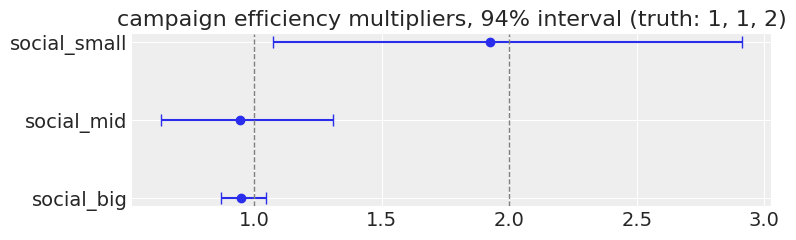

In [4]:
mult = mmm.idata.posterior["campaign_media_beta_multiplier"]
q = mult.quantile([0.03, 0.5, 0.97], dim=("chain", "draw"))

fig, ax = plt.subplots(figsize=(8, 2.5))
y_pos = np.arange(len(campaigns))
ax.errorbar(
    q.sel(quantile=0.5),
    y_pos,
    xerr=[
        q.sel(quantile=0.5) - q.sel(quantile=0.03),
        q.sel(quantile=0.97) - q.sel(quantile=0.5),
    ],
    fmt="o",
    capsize=4,
)
ax.set_yticks(y_pos, campaigns)
for v in (1.0, 2.0):
    ax.axvline(v, color="gray", ls="--", lw=1)
ax.set_title("campaign efficiency multipliers, 94% interval (truth: 1, 1, 2)")
fig.tight_layout()

## Decomposition: campaigns, and the channel roll-up

Three deterministics expose the decomposition without touching `mu`:

- `campaign_media_campaign_contribution` — per campaign, the object this whole exercise is about;
- `campaign_media_channel_contribution` — campaigns summed back to their channel, so channel ROI stays reportable;
- `campaign_media_effect_contribution` — the total that enters `mu` (the `MuEffect` contract).

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_25649/2797556097.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


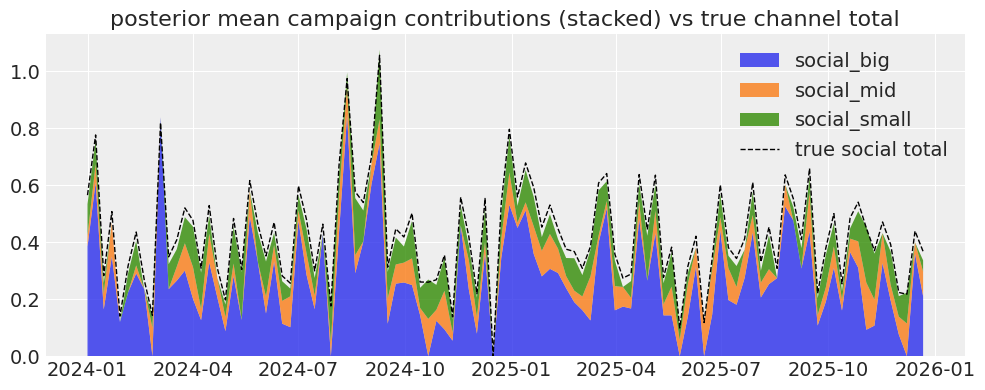

In [5]:
post = mmm.idata.posterior
target_scale = float(mmm.scalers._target)
camp_contrib = (
    post["campaign_media_campaign_contribution"].mean(("chain", "draw")) * target_scale
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(
    dates,
    [camp_contrib.sel(campaign=c).values for c in campaigns],
    labels=campaigns,
    alpha=0.8,
)
ax.plot(
    dates, contrib_camp.sum(1), color="black", lw=1, ls="--", label="true social total"
)
ax.legend(loc="upper right")
ax.set_title("posterior mean campaign contributions (stacked) vs true channel total")
fig.tight_layout()

In [6]:
# realized ROI per campaign: posterior vs truth
denom = np.where(xc.sum(0) > 0, xc.sum(0), 1.0)
true_roi = contrib_camp.sum(0) / denom
# model contributions are in scaled-target units; convert back with the target scale
target_scale = float(mmm.scalers._target)
post_roi = (
    post["campaign_media_campaign_contribution"].sum("date")
    * target_scale
    / xr.DataArray(denom, dims="campaign")
)
summary = pd.DataFrame(
    {
        "spend share": shares,
        "true ROI": true_roi.round(2),
        "posterior ROI": post_roi.mean(("chain", "draw")).values.round(2),
        "posterior sd": post_roi.std(("chain", "draw")).values.round(2),
    },
    index=campaigns,
)
summary

,spend share,true ROI,posterior ROI,posterior sd
social_big,0.7,2.02,1.84,0.14
social_mid,0.2,1.82,1.75,0.38
social_small,0.1,4.28,4.63,0.86


## The campaign saturation curves

The decomposition above is the time-series consequence; the *mechanism* is one saturation curve per campaign — the **channel curve scaled by campaign size on both axes**:

$$\text{contribution}_c(x) = \text{cap}_c^{\rho} \cdot m_c \cdot S\!\left(\frac{x}{\text{cap}_c^{\rho}}\right),$$

where $S$ is the shared channel-level saturation (Michaelis–Menten by default; any `SaturationTransformation` from the library plugs in via the `saturation=` field) and $m_c$ the campaign multiplier. This degree-1 homogeneity in size is deliberate: it makes the parameterisation *split-invariant* (splitting a campaign into halves with the same total spend leaves the channel contribution unchanged) and makes **marginal returns equal across campaigns at proportional spend** — so any marginal difference you see below had to be earned from data, not smuggled in by the parameterisation. Two reading rules:

- The shaded band on each curve marks the campaign's **observed operating range** (5–95% of its non-zero weekly spends). Inside it, the curve is informed by data; outside it, you are reading the functional form and the priors, not evidence.
- The dot marks the mean operating point. What matters for decisions is the **slope at that dot** — the marginal ROI — not the height of the curve, and marginal ROIs of campaigns whose operating ranges don't overlap are not directly comparable.

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_25649/615203057.py:39: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


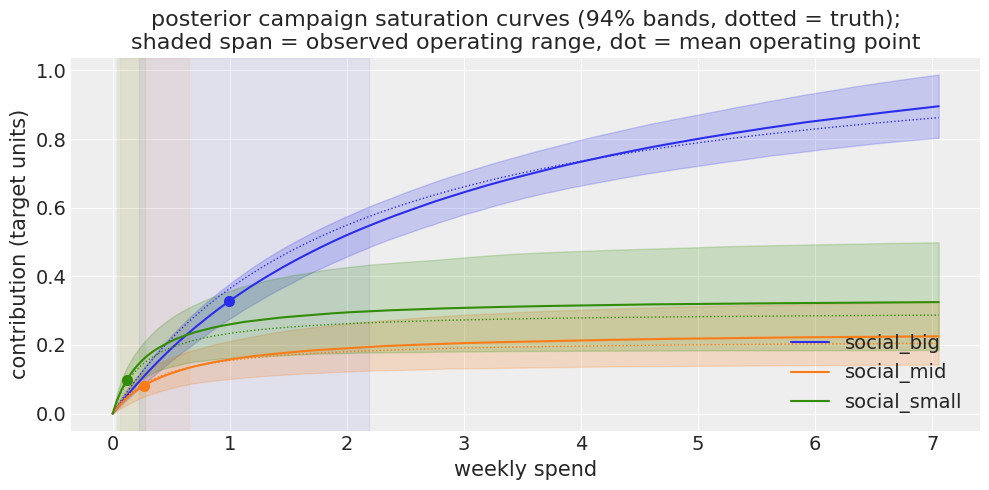

In [7]:
beta_c_post = post["campaign_media_beta_campaign"]
lam_c_post = post["campaign_media_lam_campaign"]

x_grid = np.linspace(0, campaign_spend.max() * 1.2, 200)  # raw weekly spend
xg = x_grid / s_social  # model works on channel-scaled spend

fig, ax = plt.subplots(figsize=(10, 5))
for j, c in enumerate(campaigns):
    b = beta_c_post.sel(campaign=c).values.ravel()[:, None]
    lam = lam_c_post.sel(campaign=c).values.ravel()[:, None]
    curves = b * xg[None, :] / (xg[None, :] + lam) * target_scale
    med = np.median(curves, axis=0)
    lo, hi = np.percentile(curves, [3, 97], axis=0)

    (line,) = ax.plot(x_grid, med, label=c)
    ax.fill_between(x_grid, lo, hi, alpha=0.2, color=line.get_color())

    live = campaign_spend[campaign_spend[:, j] > 0, j]
    ax.axvspan(
        np.percentile(live, 5),
        np.percentile(live, 95),
        color=line.get_color(),
        alpha=0.07,
    )
    x0 = live.mean()
    ax.plot(x0, np.interp(x0, x_grid, med), "o", color=line.get_color(), ms=7)

    # true curve for reference
    true_curve = (1.2 * true_beta_mult[j]) * cap[j] * xg / (xg + 0.35 * cap[j])
    ax.plot(x_grid, true_curve, color=line.get_color(), ls=":", lw=1)

ax.set_xlabel("weekly spend")
ax.set_ylabel("contribution (target units)")
ax.set_title(
    "posterior campaign saturation curves (94% bands, dotted = truth);\n"
    "shaded span = observed operating range, dot = mean operating point"
)
ax.legend(loc="lower right")
fig.tight_layout()

The size tie is visible immediately: `social_small` both saturates earlier *and* plateaus lower than `social_big` (its curve is the channel curve shrunk by its cap on both axes), and it is more uncertain — the band widens quickly outside its narrow operating range. The dotted truth curves stay inside the bands where there is support and can drift outside them where there is none: exactly the honest behavior we want.

The decision quantity is the slope at each campaign's own operating point, $\beta_c \lambda_c / (x_0 + \lambda_c)^2$ — this is what the `BudgetOptimizer` equalizes across cells at an interior optimum:

In [8]:
rows = {}
for j, c in enumerate(campaigns):
    live = campaign_spend[campaign_spend[:, j] > 0, j]
    x0 = live.mean() / s_social
    b = beta_c_post.sel(campaign=c)
    lam = lam_c_post.sel(campaign=c)
    # d contribution / d raw spend, in target units per spend unit
    marginal = b * lam / (x0 + lam) ** 2 * target_scale / s_social
    rows[c] = {
        "mean operating spend": round(float(live.mean()), 3),
        "marginal ROI (median)": round(float(marginal.median()), 2),
        "3%": round(float(marginal.quantile(0.03)), 2),
        "97%": round(float(marginal.quantile(0.97)), 2),
    }
pd.DataFrame(rows).T

,mean operating spend,marginal ROI (median),3%,97%
social_big,0.996,0.24,0.22,0.26
social_mid,0.269,0.20,0.13,0.27
social_small,0.119,0.57,0.36,0.75


At proportional spend the size-tied parameterisation makes marginal ROIs *equal by construction* — so the spread in this table is earned from data: `social_small`'s roughly 2× marginal advantage tracks its true 2× efficiency multiplier, not its size. (An earlier draft of this effect tied only the half-saturation to size, not the amplitude; marginal ROIs then scaled like 1/share and a 2%-share campaign looked ~35× better at the margin from the parameterisation alone — precisely the kind of artifact a budget optimizer would happily act on. The split-invariance property is now enforced by a test.)

## Where the information comes from (and when it doesn't)

A caution before celebrating: this worked because the synthetic spends had **mix variation**. In a falsification experiment where the three campaigns keep fixed 70/20/10 proportions every single week, the same 2× efficiency is **invisible**: the posterior multipliers collapse to the pooled channel mean, exactly as identification theory predicts — a split that preserves the channel mix carries no campaign-level signal.

Two practical consequences:

1. Check your spend matrix for contrasts (share variance, dark weeks) *before* promising campaign-level answers.
2. When historical contrasts are missing, bring the information from outside — covariates (the `covariate_var` field) or, best of all, **lift tests**.

## Calibrating with a campaign-level lift test

A lift test is direct experimental evidence on one campaign's curve, independent of flighting. `add_lift_test_measurements` conditions the model on the measured incremental response of a spend change `delta_x` at operating point `x` (spend units are handled internally via the campaign's channel scale).

In [9]:
df_lift = pd.DataFrame(
    {
        "campaign": ["social_small"],
        "x": [0.05 * s_social],  # operating point, spend units
        "delta_x": [0.05 * s_social],  # tested spend increase
        "delta_y": [0.10],  # measured incremental target
        "sigma": [0.03],
    }
)

mmm_lift = MMM(
    channel_columns=["search"],
    date_column="date",
    target_column="y",
    adstock=GeometricAdstock(l_max=2),
    saturation=LogisticSaturation(),
)
effect = NestedCampaignMedia(campaign_to_channel=mapping)
mmm_lift.add_mu_effect(effect)
mmm_lift.build_model(X=X, y=y)
effect.add_lift_test_measurements(df_lift, mmm_lift)
"campaign_media_lift_measurements" in mmm_lift.model.named_vars

True

## Allocating between campaigns

The `BudgetOptimizer` co-optimizes the campaigns with the remaining channels: pass `spend_vars=["campaign_data"]` and every campaign becomes a budget cell competing with `search` under one total-budget constraint. Three things to know:

- Use `response_variable="total_response_original_scale"` — the default objective is built from the channel contribution alone and cannot see `MuEffect` contributions (the model warns if you forget).
- The optimizer validates at construction that the response depends on every spend var, so a miswired objective fails loudly instead of silently starving the campaigns.
- `mmm.budget_optimizer(start, end, ...)` builds the optimization-window model for you by **cloning the fitted model**, so the effect's channel scales carry over from training automatically.

In [10]:
optimizer = mmm.budget_optimizer(
    start_date=dates[-1] + pd.Timedelta(weeks=1),
    end_date=dates[-1] + pd.Timedelta(weeks=8),
    spend_vars=["campaign_data"],
    response_variable="total_response_original_scale",
)
allocation, result = optimizer.allocate_budget(total_budget=16.0)
cells = ["search", *campaigns]
optimal = np.asarray(
    result.x, dtype=float
)  # [search | social_big, social_mid, social_small]
pd.Series(optimal, index=cells, name="optimal 8-week budget").round(2)

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_25649/2690269927.py:7: UserWarning: No budget bounds provided. Using default bounds (0, total_budget) for each channel.
  allocation, result = optimizer.allocate_budget(total_budget=16.0)


search          3.09
social_big      9.31
social_mid      1.79
social_small    1.81
Name: optimal 8-week budget, dtype: float64

social_small share of the social budget: historical 7.9% -> optimized 14.0%


/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_25649/1002181946.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


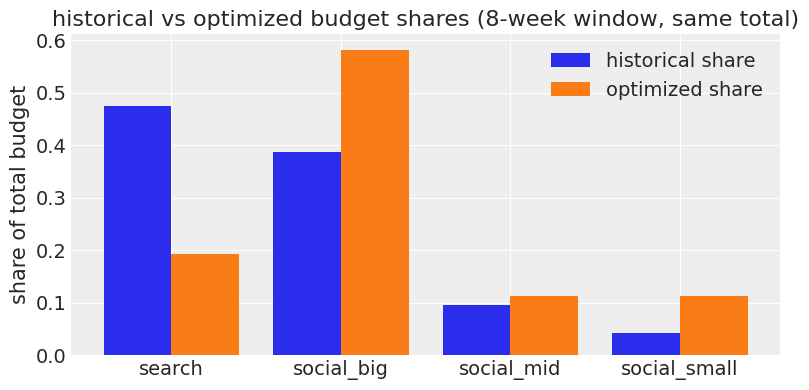

In [11]:
historical = np.r_[search_spend.mean(), campaign_spend.mean(0)] * 8
hist_share = historical / historical.sum()
opt_share = optimal / optimal.sum()

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(cells))
ax.bar(x_pos - 0.2, hist_share, width=0.4, label="historical share")
ax.bar(x_pos + 0.2, opt_share, width=0.4, label="optimized share")
ax.set_xticks(x_pos, cells)
ax.set_ylabel("share of total budget")
ax.set_title("historical vs optimized budget shares (8-week window, same total)")
ax.legend()
fig.tight_layout()

camp_opt = optimal[1:]
print(
    f"social_small share of the social budget: "
    f"historical {campaign_spend.mean(0)[2] / campaign_spend.mean(0).sum():.1%} "
    f"-> optimized {camp_opt[2] / camp_opt.sum():.1%}"
)

The optimizer moves budget within `social` toward `social_small` — the campaign whose marginal ROI at its operating point was highest in the table above. At an interior optimum those marginal ROIs are equalized across all cells, `search` included (this is verified to ~4e-5 relative spread in our stress tests).

Read the reallocation with the same honesty as the fit. Because the parameterisation is size-tied, its no-evidence allocation is *neutral*: in the falsification regime discussed earlier — fixed shares, no campaign-level evidence — the posterior multipliers collapse to 1 and the optimized share stays at the historical one (we measure 10.4% vs 10%). So the movement you see here, 10% → ~14%, is *earned by the recovered 2× multiplier*, not smuggled in by structure. The remaining disciplines still apply: decompose any allocation into *history → evidence*, and treat allocations far outside a campaign's operating range as extrapolation.

## Current limitations

- `MMM.save`/`load` does not round-trip the effect yet (the reload path rebuilds `X` as a DataFrame, which cannot carry the `campaign` dimension). Tracked as a strict `xfail`.
- No campaign-level adstock yet; carryover currently comes only from the channel-level part of the model.
- A pre-fit identifiability diagnostic (formalizing the "check your contrasts" advice above) is planned.

Recovery evidence for the pooling claim (20-seed paired study, weak-data regime): the nested effect beats flat no-pooling on 2%-share campaigns in 20/20 seeds, median error ratio 3.78×.

In [12]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Wed, 26 Aug 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4

arviz         : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
platform      : 1.0.8
pymc          : 6.2.0
pymc_marketing: 1.1.0
xarray        : 2026.4.0

Watermark: 2.6.0

